In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import (
    StratifiedGroupKFold,
    cross_validate,
    cross_val_predict
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

OUT = Path("outputs")
OUT.mkdir(exist_ok=True)

df = pd.read_csv(
    OUT / "sparrow_model_data.csv",
    dtype={"ID": str}
)

train = df.loc[df["Split"] == "train"].copy()
train = train.reset_index(drop=True)

features = [
    "BuildingHeight",
    "BuildingWidth",
    "Altitude",
    "AveNoise",
    "temp",
    "prec",
    "win"
]

X = train[features]
y = train["NestCount"]
groups = train["ID"]

assert not X.isna().any().any()
assert not y.isna().any()
assert not groups.isna().any()

print("Training rows:", len(train))
print("Spatial groups:", groups.nunique())
print("\nTarget summary:")
print(y.describe())

Training rows: 501
Spatial groups: 28

Target summary:
count    501.000000
mean       5.668663
std        5.624055
min        1.000000
25%        2.000000
50%        4.000000
75%        7.000000
max       50.000000
Name: NestCount, dtype: float64


In [2]:
# construct validation folds not mixing the group
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(
    cv.split(
        X,
        train["HigherNestCount"],
        groups=groups
    )
)

fold_rows = []

for fold_number, (fit_idx, val_idx) in enumerate(folds, start=1):
    fit_groups = set(groups.iloc[fit_idx])
    val_groups = set(groups.iloc[val_idx])

    overlap = fit_groups & val_groups
    assert len(overlap) == 0

    fold_rows.append({
        "Fold": fold_number,
        "TrainRows": len(fit_idx),
        "ValidationRows": len(val_idx),
        "GroupOverlap": len(overlap)
    })

fold_info = pd.DataFrame(fold_rows)
display(fold_info)

,Fold,TrainRows,ValidationRows,GroupOverlap
0,1,404,97,0
1,2,400,101,0
2,3,382,119,0
3,4,407,94,0
4,5,411,90,0


In [3]:
# models
models = {
    "Baseline Mean": DummyRegressor(strategy="mean"),

    "Baseline Median": DummyRegressor(strategy="median"),

    "Linear Regression": make_pipeline(
        StandardScaler(),
        LinearRegression()
    ),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=3,
        min_samples_leaf=10,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
}

In [4]:
# set metrics and make cross-validation
scoring = {
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "r2": "r2"
}

summary_rows = []
detail_rows = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=folds,
        scoring=scoring,
        error_score="raise",
        n_jobs=1
    )

    mae = -scores["test_mae"]
    rmse = np.sqrt(-scores["test_mse"])
    r2 = scores["test_r2"]

    summary_rows.append({
        "Model": name,
        "MAE_mean": mae.mean(),
        "MAE_std": mae.std(ddof=1),
        "RMSE_mean": rmse.mean(),
        "RMSE_std": rmse.std(ddof=1),
        "R2_mean": r2.mean(),
        "R2_std": r2.std(ddof=1)
    })

    for i in range(len(folds)):
        detail_rows.append({
            "Model": name,
            "Fold": i + 1,
            "MAE": mae[i],
            "RMSE": rmse[i],
            "R2": r2[i]
        })

results = pd.DataFrame(summary_rows).sort_values(
    "MAE_mean"
).reset_index(drop=True)

fold_results = pd.DataFrame(detail_rows)

display(results.round(3))

,Model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,Decision Tree,2.824,0.990,4.354,1.999,0.227,0.145
1,Random Forest,2.827,0.991,4.291,1.942,0.219,0.279
2,Linear Regression,3.209,1.202,4.525,2.021,0.145,0.227
3,Baseline Median,3.388,1.405,5.336,2.759,-0.094,0.083
4,Baseline Mean,3.708,1.173,5.277,2.481,-0.116,0.116


In [5]:
# compare with baseline
baseline_names = ["Baseline Mean", "Baseline Median"]

best_baseline = (
    results[results["Model"].isin(baseline_names)]
    .sort_values("MAE_mean")
    .iloc[0]
)

best_learned = (
    results[~results["Model"].isin(baseline_names)]
    .sort_values("MAE_mean")
    .iloc[0]
)

improvement = 100 * (
    best_baseline["MAE_mean"] - best_learned["MAE_mean"]
) / best_baseline["MAE_mean"]

print("Best baseline:", best_baseline["Model"])
print("Best learned model:", best_learned["Model"])
print(f"MAE improvement over baseline: {improvement:.2f}%")

if improvement <= 0:
    print("The learned model did not beat the best baseline on mean MAE.")

Best baseline: Baseline Median
Best learned model: Decision Tree
MAE improvement over baseline: 16.63%


In [7]:
# check the un-seen fold's prediction
selected_name = str(best_learned["Model"])

oof_pred = cross_val_predict(
    clone(models[selected_name]),
    X,
    y,
    cv=folds,
    method="predict",
    n_jobs=1
)

prediction_table = train[
    ["SourceRowIndex", "Building#", "ID", "NestCount"]
].copy()

prediction_table["Model"] = selected_name
prediction_table["PredictedNestCount"] = oof_pred
prediction_table["Residual"] = y.to_numpy() - oof_pred
prediction_table["AbsoluteError"] = np.abs(
    prediction_table["Residual"]
)

print("Model:", selected_name)
print("Negative predictions:", int((oof_pred < 0).sum()))

display(prediction_table.head(10))

Model: Decision Tree
Negative predictions: 0


,SourceRowIndex,Building#,ID,NestCount,Model,PredictedNestCount,Residual,AbsoluteError
0,0,Building 11,11640,17,Decision Tree,9.842105,7.157895,7.157895
1,1,Building 3,11640,13,Decision Tree,9.842105,3.157895,3.157895
2,2,Building 8-1,11640,10,Decision Tree,9.842105,0.157895,0.157895
3,3,Building 8-2,11640,13,Decision Tree,9.842105,3.157895,3.157895
4,4,Building 9-1,11640,9,Decision Tree,9.842105,-0.842105,0.842105
5,5,Building 9-2,11640,6,Decision Tree,9.842105,-3.842105,3.842105
6,6,SOHO,10237,6,Decision Tree,3.151786,2.848214,2.848214
7,7,Aerding Community Building 25,11041,3,Decision Tree,4.506667,-1.506667,1.506667
8,8,Aerding Community Building 26,11041,2,Decision Tree,6.162602,-4.162602,4.162602
9,9,Aerding Community Building 29,11041,4,Decision Tree,4.506667,-0.506667,0.506667


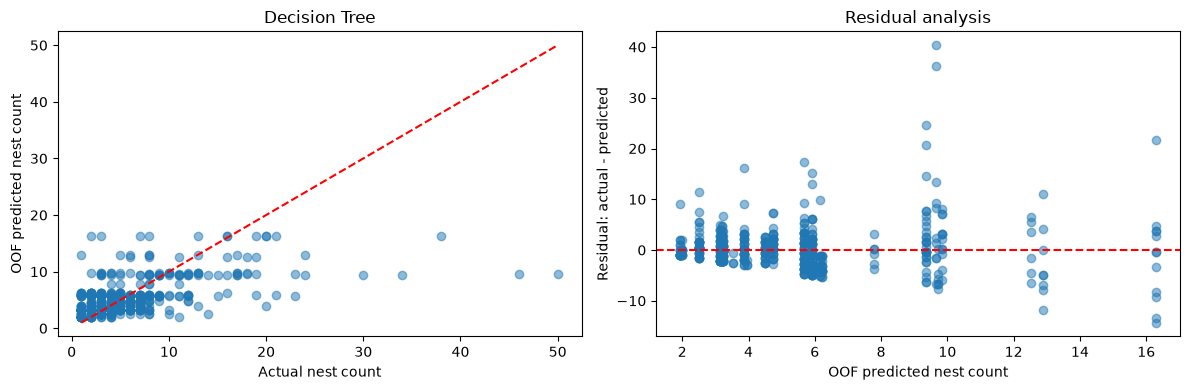

In [8]:
# check prediction error with diagram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y, oof_pred, alpha=0.5)

low = min(float(y.min()), float(oof_pred.min()))
high = max(float(y.max()), float(oof_pred.max()))

axes[0].plot([low, high], [low, high], "r--")
axes[0].set_xlabel("Actual nest count")
axes[0].set_ylabel("OOF predicted nest count")
axes[0].set_title(selected_name)

residuals = y.to_numpy() - oof_pred

axes[1].scatter(oof_pred, residuals, alpha=0.5)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("OOF predicted nest count")
axes[1].set_ylabel("Residual: actual - predicted")
axes[1].set_title("Residual analysis")

plt.tight_layout()
plt.savefig(OUT / "regression_diagnostics.png", dpi=200)
plt.show()

In [9]:
# save the results
results.to_csv(
    OUT / "regression_cv_results.csv",
    index=False
)

fold_results.to_csv(
    OUT / "regression_cv_fold_results.csv",
    index=False
)

prediction_table.to_csv(
    OUT / "regression_oof_predictions.csv",
    index=False
)

print("Regression results saved.")

Regression results saved.
